## A short notebook tutorial on Gaussian Process Regression w/ SuperMAG data

*Last Modified*: July 24th, 2024

Author: [Opal Issan](https://opaliss.github.io/opalissan/) (PhD student @UCSD). contact: oissan@ucsd.edu

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np 
import scipy
import cartopy.crs as ccrs
from supermag_api import * 
import GPy
from IPython.display import display
from scipy.stats import pearsonr
from spherical_harmonics import get_spherical_harmonic_basis_matrix, ridge_regression, construct_global_view

In [3]:
import matplotlib.pyplot as plt
import matplotlib
from mycolorpy import colorlist as mcp
font = {'family' : 'serif',
        'size'   : 14}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 

## SuperMAG data

In [6]:
# start date year-month-day-hour-min-sec
# St. Patricks Day Storm
start=[2015, 3, 17, 18, 40, 10] 

In [7]:
# read in data
(status,stations) = SuperMAGGetInventory("opaliss", start, 3600)
# number of stations
N = len(stations)
print("number of stations = ", N)

number of stations =  238


In [9]:
# intialize data
data_Bn = np.zeros(N)
data_Be = np.zeros(N)
data_Bz = np.zeros(N)
geo_lat = np.zeros(N)
geo_lon = np.zeros(N)

In [11]:
# read in data for 1hr in advance from start date at station "res"
# note: this is very slow.. not sure if there are faster ways to go about this
kk=0
for ii in range(0, N):
    (status, sm_data) = SuperMAGGetData("opaliss", start, 3600, 'geo', stations[ii])
    try:
        data_Bn[kk] = sm_data.N[0]["geo"]
        data_Be[kk] = sm_data.E[0]["geo"]
        data_Bz[kk] = sm_data.Z[0]["geo"]
        geo_lat[kk] = sm_data.glat[0]
        geo_lon[kk] = sm_data.glon[0]
        kk+=1
    except:
        print("An exception occurred at " + str(stations[ii]))
        
data_Bn = data_Bn[:kk]
data_Be = data_Be[:kk]
data_Bz = data_Bz[:kk]
geo_lat = geo_lat[:kk]
geo_lon = geo_lon[:kk]

An exception occurred at AAA
An exception occurred at AMD
An exception occurred at BRW
An exception occurred at YAP


## 2D regression *without* spherical harmonic assumption 
#### radial basis function kriging: squared exponential

\begin{aligned}x&=r\sin \theta \,\cos \varphi ,\\y&=r\sin \theta \,\sin \varphi ,\\z&=r\cos \theta .\end{aligned}



In [12]:
def spherical_to_cartesian(latitude, longitude, radius=6371):
    x = radius * np.sin(latitude*np.pi/180) * np.cos(longitude*np.pi/180)
    y = radius * np.sin(latitude*np.pi/180) * np.sin(longitude*np.pi/180)
    z = radius * np.cos(latitude*np.pi/180)
    return np.array([x, y, z])

In [13]:
# sample inputs and outputs
X = spherical_to_cartesian(latitude=geo_lat+90, longitude=geo_lon, radius=6371)
Y = np.reshape(data_Bn, (len(data_Bn), 1))

In [14]:
def great_circle(lon1, lat1, lon2, lat2):
    # in km
    return 6371 * (np.acos(np.sin(lat1*np.pi/180) * np.sin(lat2*np.pi/180) + np.cos(lat1*np.pi/180) * np.cos(lat2*np.pi/180) * np.cos(lon1*np.pi/180 - lon2*np.pi/180)))

In [15]:
# setup kernel + its hyperparameters
kernel = GPy.kern.RBF(input_dim=3, variance=1., lengthscale=1.)

In [16]:
# create simple GP model
m = GPy.models.GPRegression(X.T, Y,kernel)
# optimize
#m.Gaussian_noise.constrain_bounded(1, 300)
m.optimize(messages=True, max_f_eval = 100)

Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s02  0003   1.762895e+06   2.513928e+11 
    00s06  0008   3.928346e+05   7.770350e+08 
    00s10  0013   9.690421e+04   2.802803e+06 
    00s16  0022   8.309048e+03   2.000123e+02 
    00s19  0027   2.055014e+03   9.732733e-02 
    00s34  0065   1.447576e+03   1.851800e-11 
Runtime:     00s34
Optimization status: Converged



In [17]:
m

GP_regression.,value,constraints,priors
rbf.variance,43606.186022032256,+ve,
rbf.lengthscale,874.7774184118658,+ve,
Gaussian_noise.variance,3126.8108215406546,+ve,


In [18]:
# location of prediction mesh grid
N_pred = 700
TT, PP = np.meshgrid(np.linspace(0, 180, N_pred, endpoint=False), 
                     np.linspace(0, 360, N_pred, endpoint=False))

XX, YY, ZZ = spherical_to_cartesian(latitude=TT, longitude=PP, radius=6371)

In [19]:
A, B = m.predict(Xnew=np.array([np.ndarray.flatten(XX, "C"), 
                                np.ndarray.flatten(YY, "C"), 
                                np.ndarray.flatten(ZZ, "C")]).T)

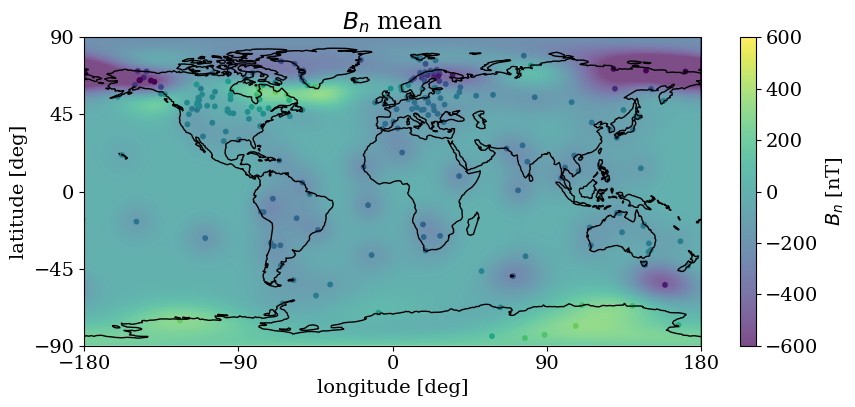

In [21]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(PP, TT-90, np.reshape(A, (N_pred, N_pred)),
                    alpha=0.7, transform=ccrs.PlateCarree(), vmin=-600, vmax=600, shading="nearest")

plt.scatter(geo_lon, geo_lat, c=data_Bn, s=10, cmap='viridis', vmin=-600, vmax=600, transform=ccrs.PlateCarree())
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ mean")
#ax.set_xlim(-180, 180)
#ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/mean_rbf.png", bbox_inches='tight', dpi=600)

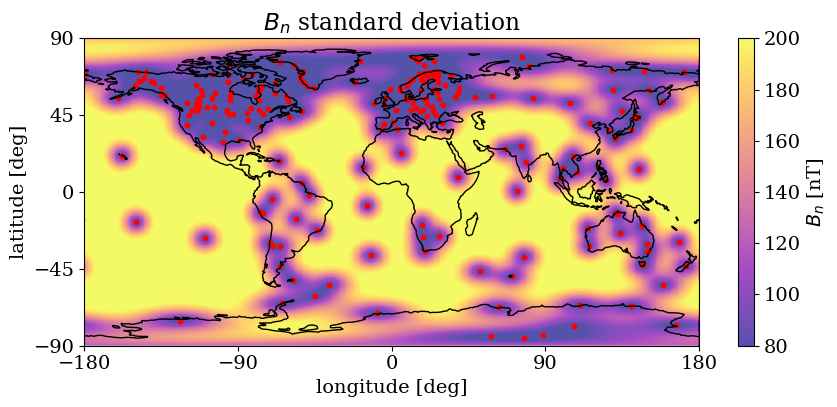

In [24]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(PP, TT-90, np.reshape(np.sqrt(B), (N_pred, N_pred)), alpha=0.7, transform=ccrs.PlateCarree(),
                    cmap="plasma", shading="nearest", vmin=80, vmax=200)

plt.scatter(geo_lon, geo_lat, s=10, c='red')
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ standard deviation")
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/std_rbf.png", bbox_inches='tight', dpi=600)

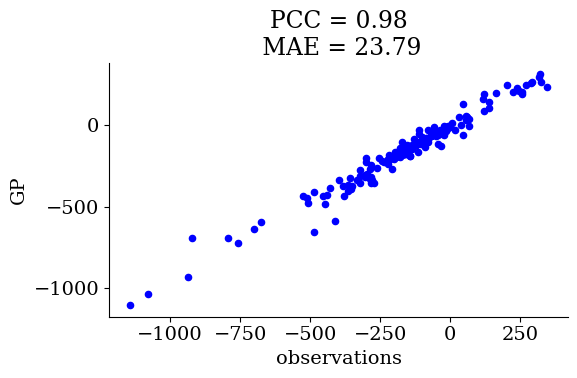

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))

corr, _ = pearsonr(Y[:, 0], m.predict(Xnew=X.T)[0][:, 0])
mae = np.mean(np.abs(Y[:, 0]- m.predict(Xnew=X.T)[0][:, 0]))

ax.scatter(Y, m.predict(Xnew=X.T)[0], label="GP", color="blue", s=20)
ax.set_title("PCC = " + str(round(corr, 2)) + "\n MAE = " + str(round(mae, 2)))
ax.set_xlabel("observations")
ax.set_ylabel("GP")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/rbf_error.png", dpi=600)

## 2D Regression *with* Spherical Harmonic assumption 

In [39]:
# sample inputs and outputs
ell = 10
X = get_spherical_harmonic_basis_matrix(latitude=(geo_lat+90)*np.pi/180, longitude=geo_lon*np.pi/180, ell=ell)
Y = np.reshape(data_Bn, (len(data_Bn), 1))

In [40]:
# setup kernel + its hyperparameters
kernel = GPy.kern.Linear(input_dim=(ell+1)**2, variances=1)

In [41]:
np.shape(X)

(234, 121)

In [42]:
# create simple GP model
m = GPy.models.GPRegression(X, Y,kernel)
# optimize
#m.Gaussian_noise.constrain_bounded(1, 20)
m.optimize(messages=True, max_f_eval = 10000)

Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s02  0003   6.256255e+05   3.920699e+10 
    00s06  0010   7.837493e+04   1.220828e+07 
    00s09  0014   2.602728e+04   1.354582e+05 
    00s11  0019   7.141643e+03   4.843671e+02 
    00s13  0021   4.546156e+03   5.058118e+01 
    00s18  0030   1.586600e+03   1.512413e-03 
    00s21  0039   1.498633e+03   1.315048e-11 
Runtime:     00s21
Optimization status: Converged



In [43]:
m

GP_regression.,value,constraints,priors
linear.variances,7935.7061098811155,+ve,
Gaussian_noise.variance,12708.727461080078,+ve,


In [44]:
# location of prediction mesh grid
N_pred = 700
XX, YY = np.meshgrid(np.linspace(0, 180, N_pred, endpoint=False), 
                     np.linspace(0, 360, N_pred, endpoint=False))

X_pred = get_spherical_harmonic_basis_matrix(latitude=np.ndarray.flatten(XX, "C")*np.pi/180, 
              
                                             longitude=np.ndarray.flatten(YY, "C")*np.pi/180, 
                                             ell=ell)

In [45]:
A, B = m.predict(Xnew=X_pred)

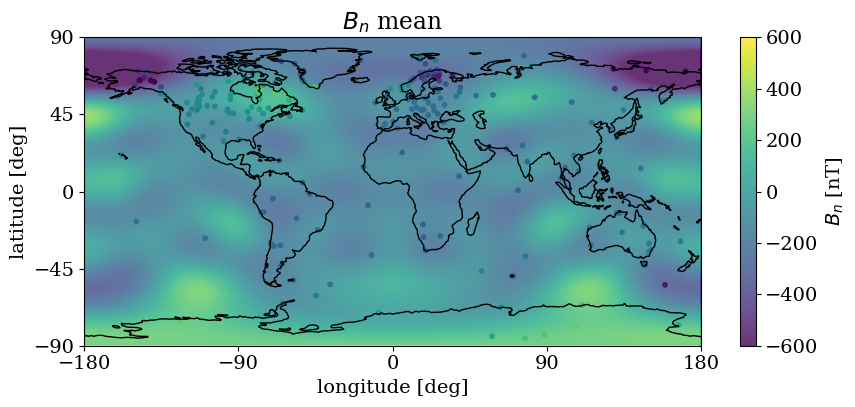

In [46]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(YY, XX-90, np.reshape(A, (N_pred, N_pred), "C"), alpha=0.8, 
                    transform=ccrs.PlateCarree(), vmin=-600, vmax=600)
plt.scatter(geo_lon, geo_lat, c=data_Bn, s=10, cmap='viridis', vmin=-600, vmax=600, transform=ccrs.PlateCarree())

cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ mean")
#ax.set_xlim(-180, 180)
#ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/mean_sph_linear.png", bbox_inches='tight', dpi=600)

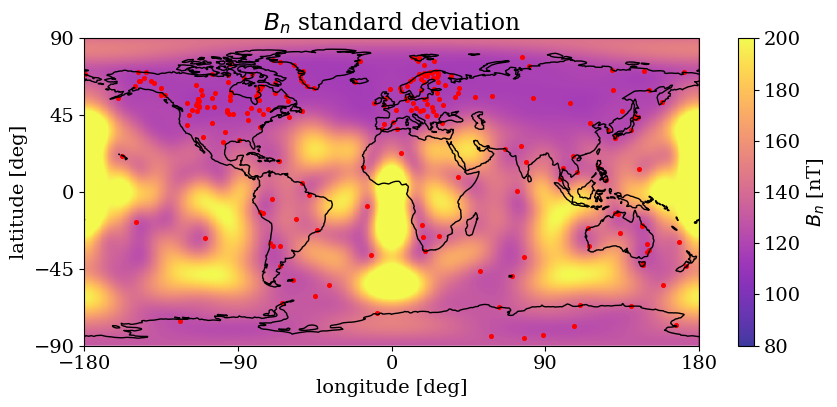

In [47]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(YY, XX-90, np.reshape(np.sqrt(B), (N_pred, N_pred), "C"), 
                    alpha=0.8, transform=ccrs.PlateCarree(), cmap="plasma", shading="nearest", vmin=80, vmax=200)

plt.scatter(geo_lon, geo_lat, c="red", s=7)
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)
ax.set_xticks([-180, -90, 0, 90, 180])
ax.set_yticks([-90, -45, 0, 45, 90])
ax.set_title("$B_{n}$ standard deviation")
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/std_sph_linear.png", bbox_inches='tight', dpi=600)

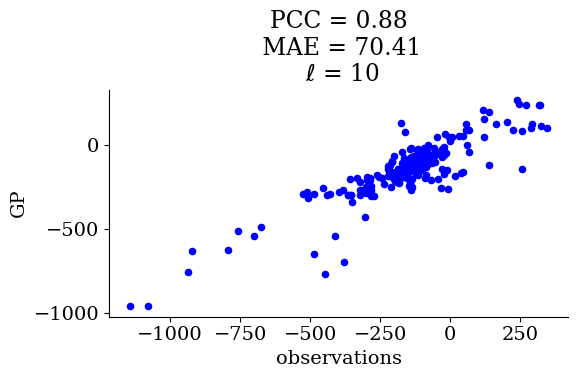

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))


y_pred = m.predict(Xnew=X)[0][:, 0]
corr, _ = pearsonr(Y[:, 0], y_pred)
mae = np.mean(np.abs(Y[:, 0] - y_pred))

ax.scatter(Y, y_pred, label="GP", color="blue", s=20)
ax.set_title("PCC = " + str(round(corr, 2)) + "\n MAE = " + str(round(mae, 2)) + "\n $\ell$ = " + str(ell))
ax.set_xlabel("observations")
ax.set_ylabel("GP")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/rbf_error_ell_" + str(ell) + ".png", dpi=600)